In [1]:
import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils
from aeon.visualisation import plot_critical_difference
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect()

/tmp/ipykernel_1345889/2919427637.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect()


In [3]:
pl.Config.set_tbl_rows(100)

def model_counts(df: pl.LazyFrame) -> pl.DataFrame:
    return (
        df
        .group_by("model", "resampled")
        .agg(pl.len().alias("count"))
        .pivot(on="resampled", values="count", index="model")
        .sort("model")
    )

rdf.pipe(model_counts)

model,false,true
str,u32,u32
"""catch22""",640,640
"""cumsum-mr-hydra""",640,120
"""difference-mr-hydra""",640,604
"""downsample-mr-hydra""",640,600
"""drcif""",640,640
"""fast-stacker-v4-r1""",159,null
"""fast-stacker-v5-r1""",84,null
"""fast-stacker-v5-r3""",56,null
"""hivecotev2""",615,95


In [4]:
def filter_results(rdf, resampled: bool = False):
    excluded_models = [
        "stacker-v4-r3",
        "difference-mr-hydra",
        "scale-mr-hydra",
        "cumsum-mr-hydra",
        "downsample-mr-hydra",
        "rank-mr-hydra",
        "polar-magnitude-mr-hydra",
        "polar-angle-mr-hydra",
        "catch22",
        "fast-stacker-v4-r1",
        "fast-stacker-v5-r1",
        "fast-stacker-v5-r3",
        "quant-catboost",
        "stacker-v4-r1"
    ]
    
    return (
        rdf
        .filter(~pl.col("model").is_in(excluded_models))
        .filter(pl.col("resampled") == resampled)
    )

df = filter_results(rdf, resampled=False)
df.pipe(model_counts)

model,false
str,u32
"""drcif""",640
"""hivecotev2""",615
"""loky-stacker-v5-r1""",640
"""mr-hydra""",640
"""mr-hydra-baseline""",640
"""mr-hydra-kbest-1000""",630
"""mr-hydra-kbest-10000""",634
"""mr-hydra-kbest-3000""",633
"""mr-hydra-kbest-30000""",628


In [5]:
def pivot(df):
    return df.pivot(
        on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
    ).drop_nulls()

127


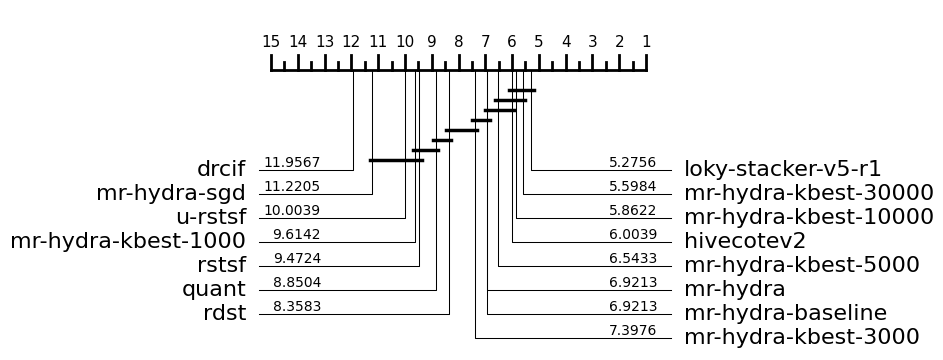

In [6]:
v = df.pipe(pivot)
methods = df["model"].unique().to_list()
plot_critical_difference(v.select(methods).to_numpy(), methods)
print(len(v))
directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

plt.savefig(f"{directory}/critical_difference_no_resampling.pdf", bbox_inches='tight', pad_inches=0)

In [7]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [8]:
joined = v.join(stats, on="dataset").sort("n_train")
#joined

63


(<Figure size 600x340 with 1 Axes>, <Axes: >)

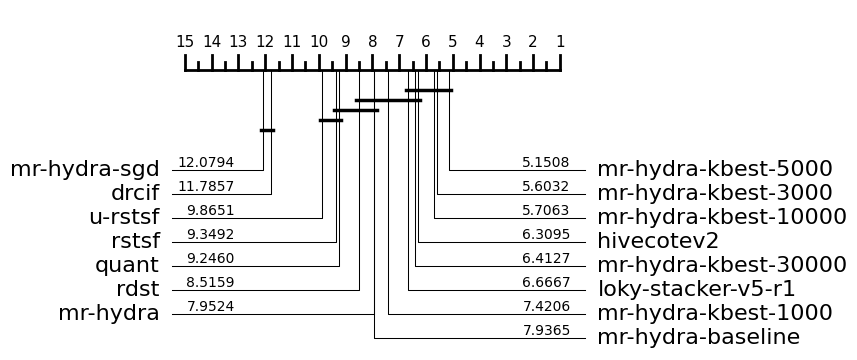

In [9]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

43


(<Figure size 600x340 with 1 Axes>, <Axes: >)

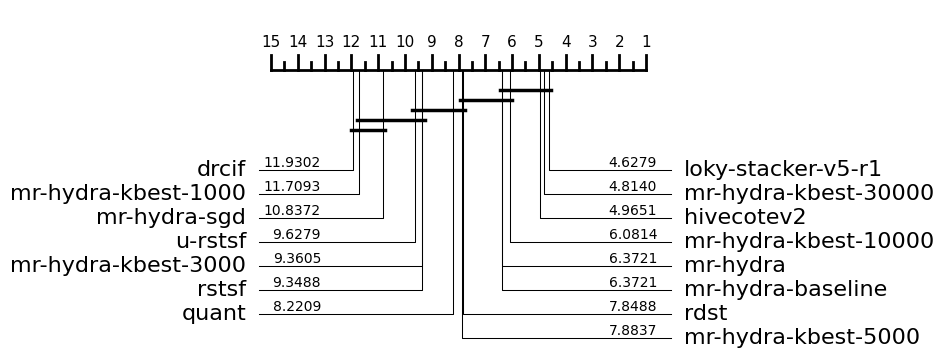

In [10]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

21


(<Figure size 600x340 with 1 Axes>, <Axes: >)

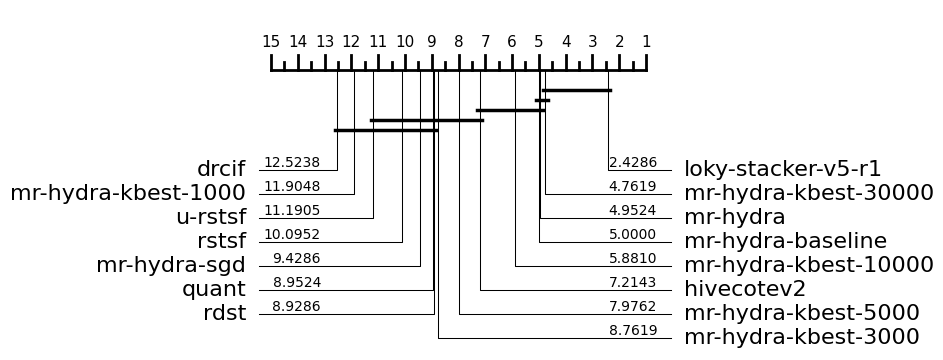

In [11]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [12]:
df = filter_results(rdf, resampled=True)
df.pipe(model_counts)

model,true
str,u32
"""drcif""",640
"""hivecotev2""",95
"""loky-stacker-v5-r1""",639
"""mr-hydra""",640
"""mr-hydra-baseline""",640
"""mr-hydra-kbest-1000""",631
"""mr-hydra-kbest-10000""",627
"""mr-hydra-kbest-3000""",633
"""mr-hydra-kbest-30000""",632


69

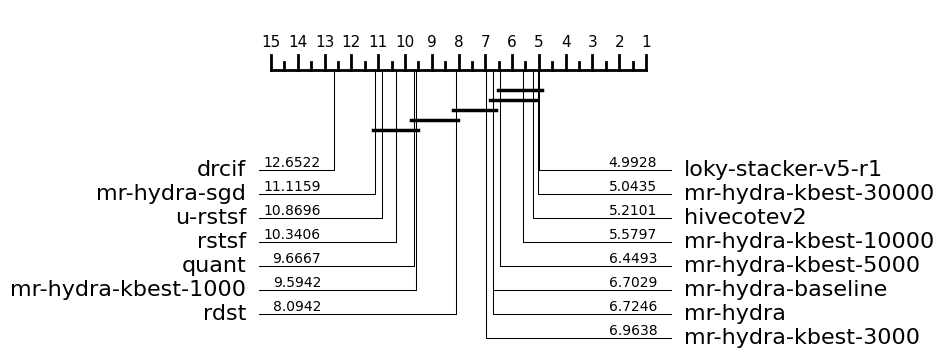

In [13]:
v = df.pipe(pivot)
methods = df["model"].unique().to_list()
plot_critical_difference(v.select(methods).to_numpy(), methods)
len(v)

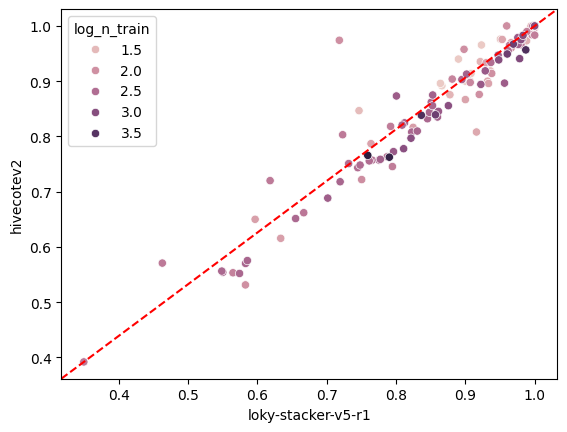

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = joined.to_pandas()
plot_df["log_n_train"] = np.log10(plot_df["n_train"])

sns.scatterplot(data=plot_df, x='loky-stacker-v5-r1', y='hivecotev2', hue='log_n_train')
plt.plot([0, 1], [0, 1], transform=plt.gca().transAxes, color='red', linestyle='--')

In [15]:
v

dataset,drcif,loky-stacker-v5-r1,mr-hydra-kbest-1000,u-rstsf,mr-hydra-baseline,mr-hydra-kbest-5000,rdst,rstsf,quant,mr-hydra-sgd,mr-hydra,mr-hydra-kbest-30000,mr-hydra-kbest-10000,mr-hydra-kbest-3000,hivecotev2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Worms""",0.706494,0.766234,0.709091,0.722944,0.727273,0.748052,0.711688,0.737662,0.711688,0.683117,0.727273,0.748052,0.763636,0.737662,0.779221
"""SemgHandMovementCh2""",0.855111,0.869778,0.597333,0.846222,0.783111,0.642667,0.701333,0.872889,0.847556,0.688148,0.783111,0.786667,0.692444,0.659111,0.877778
"""PLAID""",0.893482,0.945996,0.899441,0.884544,0.940782,0.942644,0.925512,0.890875,0.920298,0.900372,0.940782,0.947486,0.944879,0.932216,0.905028
"""AllGestureWiimoteZ""",0.588857,0.738286,0.701429,0.653214,0.739143,0.722857,0.685429,0.661143,0.675714,0.686786,0.739143,0.752857,0.738214,0.713143,0.735714
"""SmoothSubspace""",0.986667,0.998667,0.972,0.98,0.986667,0.985333,1.0,0.976,0.989333,0.97,0.986667,0.981333,0.988,0.985333,0.993333
"""PigAirwayPressure""",0.265385,0.725,0.896154,0.484375,0.725,0.952885,0.776923,0.304808,0.454808,0.641827,0.725,0.933654,0.946154,0.944231,0.975962
"""MoteStrain""",0.899361,0.932428,0.90623,0.932708,0.909904,0.913259,0.931949,0.936102,0.939936,0.876997,0.909904,0.915016,0.916773,0.914537,0.920128
"""Beef""",0.813333,0.786667,0.775,0.74,0.8,0.793333,0.706667,0.806667,0.806667,0.7,0.8,0.806667,0.806667,0.806667,0.766667
"""MixedShapesSmallTrain""",0.911835,0.963876,0.95967,0.914742,0.961485,0.964454,0.965031,0.921567,0.937897,0.946392,0.961485,0.963629,0.964454,0.965031,0.943093
